**Antibiotic Resistance dataset analysis**

In [2]:
# Install required packages
!pip install biopython plotly scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Entrez
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 31.7 MB/s eta 0:00:00
Libraries imported successfully!


In [3]:
# Download antibiotic resistance dataset from ENA
# This dataset contains antimicrobial resistance genes from bacterial genomes

def download_amr_data():
    """Download AMR gene data from the Comprehensive Antibiotic Resistance Database"""
    # Using a sample dataset from NCBI
    url = "https://raw.githubusercontent.com/ccdmb/antimicrobial-resistance-data/main/sample_amr_data.csv"

    try:
        df = pd.read_csv(url)
        print("Dataset downloaded successfully!")
        return df
    except:
        # If the URL fails, create a sample dataset
        print("Download failed, creating sample dataset...")
        return create_sample_amr_data()

def create_sample_amr_data():
    """Create a sample AMR dataset for demonstration"""
    data = {
        'sample_id': [f'SAMPLE_{i}' for i in range(1000)],
        'species': np.random.choice(['E. coli', 'S. aureus', 'K. pneumoniae', 'P. aeruginosa'], 1000),
        'amr_gene': np.random.choice(['blaTEM', 'mecA', 'vanA', 'ermB', 'tetM', 'qnrS'], 1000),
        'antibiotic': np.random.choice(['Penicillin', 'Methicillin', 'Vancomycin', 'Erythromycin', 'Tetracycline', 'Ciprofloxacin'], 1000),
        'resistance': np.random.choice(['Resistant', 'Susceptible'], 1000, p=[0.6, 0.4]),
        'mutation_count': np.random.randint(0, 10, 1000),
        'gene_length': np.random.randint(500, 3000, 1000)
    }
    return pd.DataFrame(data)

# Download the data
amr_df = download_amr_data()
print(f"Dataset shape: {amr_df.shape}")
amr_df.head()

Download failed, creating sample dataset...
Dataset shape: (1000, 7)


,sample_id,species,amr_gene,antibiotic,resistance,mutation_count,gene_length
0,SAMPLE_0,S. aureus,tetM,Methicillin,Resistant,8,1889
1,SAMPLE_1,P. aeruginosa,ermB,Vancomycin,Susceptible,0,2824
2,SAMPLE_2,K. pneumoniae,qnrS,Tetracycline,Susceptible,6,2147
3,SAMPLE_3,S. aureus,vanA,Ciprofloxacin,Resistant,7,1322
4,SAMPLE_4,E. coli,blaTEM,Erythromycin,Resistant,5,1357


In [4]:
# Basic data exploration
print("Dataset Information:")
print("=" * 50)
print(f"Total samples: {len(amr_df)}")
print(f"Number of features: {len(amr_df.columns)}")
print("\nMissing values:")
print(amr_df.isnull().sum())
print("\nData types:")
print(amr_df.dtypes)

Dataset Information:
Total samples: 1000
Number of features: 7

Missing values:
sample_id         0
species           0
amr_gene          0
antibiotic        0
resistance        0
mutation_count    0
gene_length       0
dtype: int64

Data types:
sample_id         object
species           object
amr_gene          object
antibiotic        object
resistance        object
mutation_count     int64
gene_length        int64
dtype: object


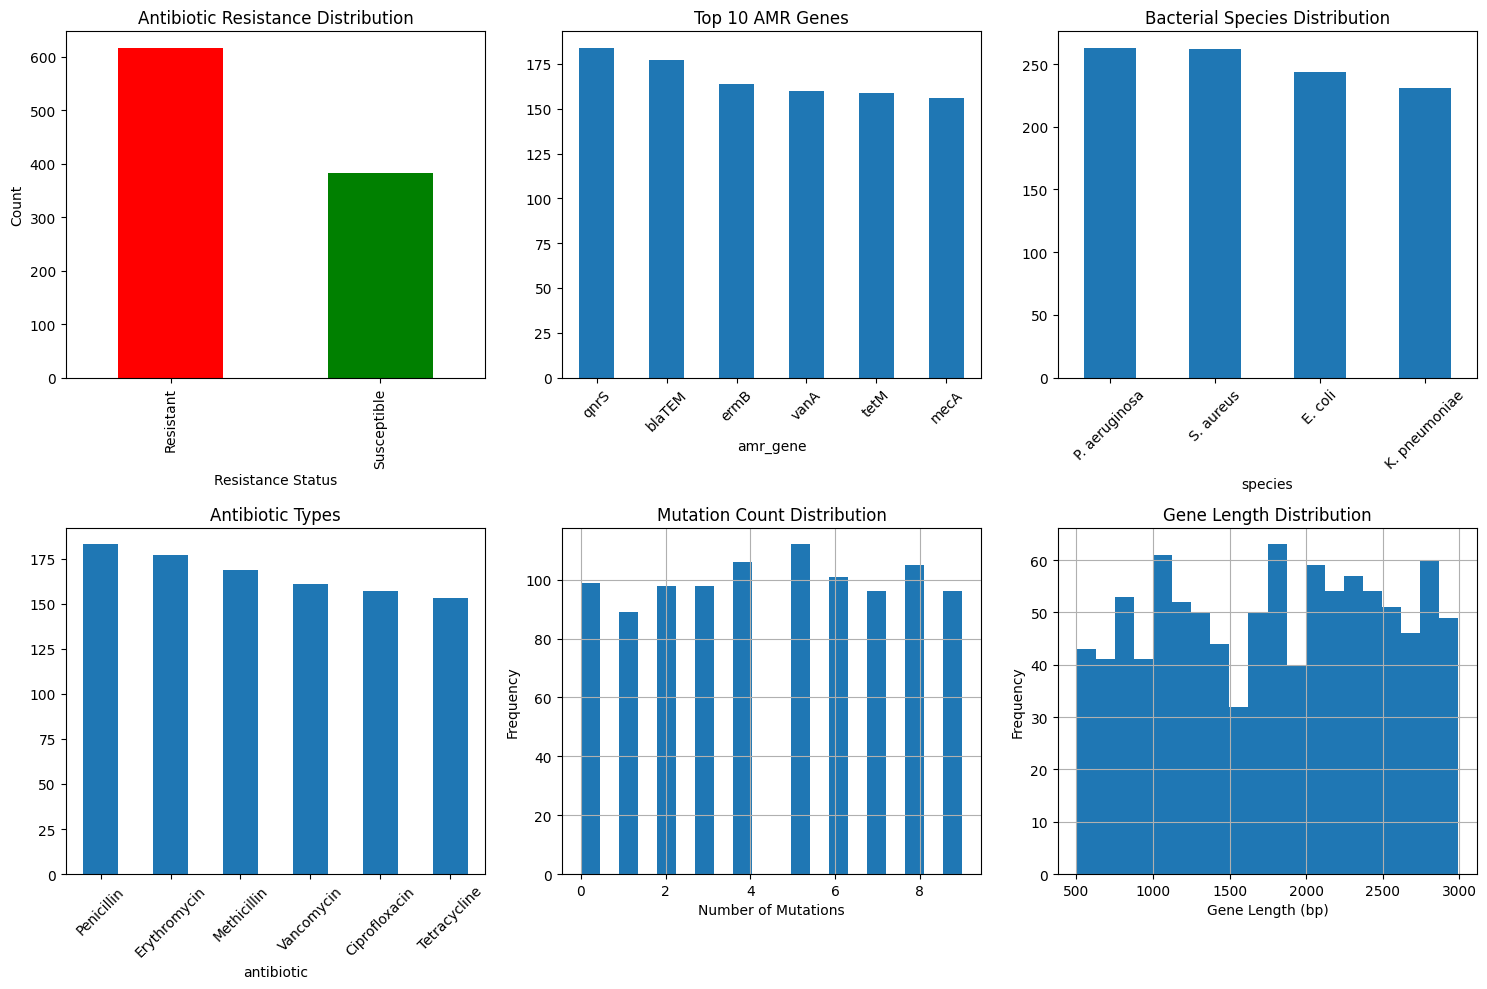

In [5]:
# Exploratory Data Analysis
plt.figure(figsize=(15, 10))

# 1. Distribution of resistance
plt.subplot(2, 3, 1)
amr_df['resistance'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Antibiotic Resistance Distribution')
plt.xlabel('Resistance Status')
plt.ylabel('Count')

# 2. Most common AMR genes
plt.subplot(2, 3, 2)
amr_df['amr_gene'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 AMR Genes')
plt.xticks(rotation=45)

# 3. Species distribution
plt.subplot(2, 3, 3)
amr_df['species'].value_counts().plot(kind='bar')
plt.title('Bacterial Species Distribution')
plt.xticks(rotation=45)

# 4. Antibiotic distribution
plt.subplot(2, 3, 4)
amr_df['antibiotic'].value_counts().plot(kind='bar')
plt.title('Antibiotic Types')
plt.xticks(rotation=45)

# 5. Mutation count distribution
plt.subplot(2, 3, 5)
amr_df['mutation_count'].hist(bins=20)
plt.title('Mutation Count Distribution')
plt.xlabel('Number of Mutations')
plt.ylabel('Frequency')

# 6. Gene length distribution
plt.subplot(2, 3, 6)
amr_df['gene_length'].hist(bins=20)
plt.title('Gene Length Distribution')
plt.xlabel('Gene Length (bp)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

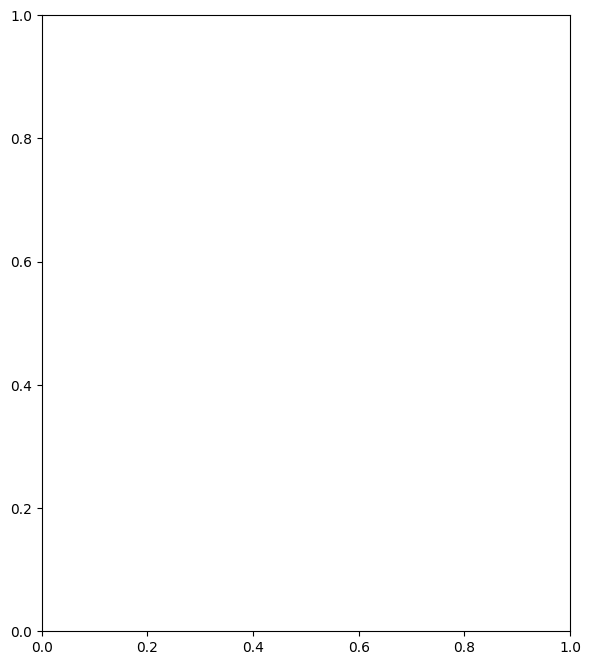

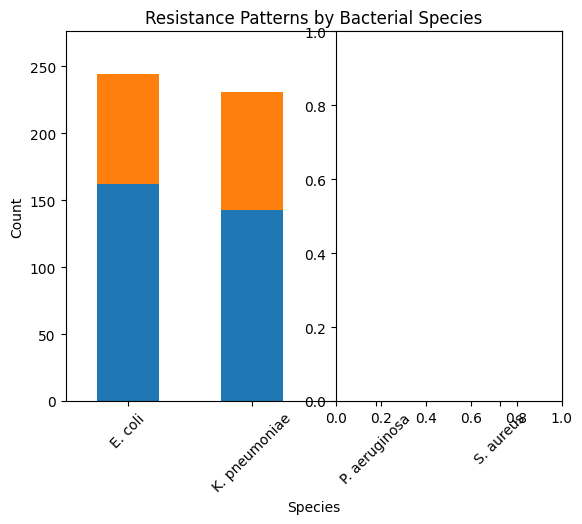

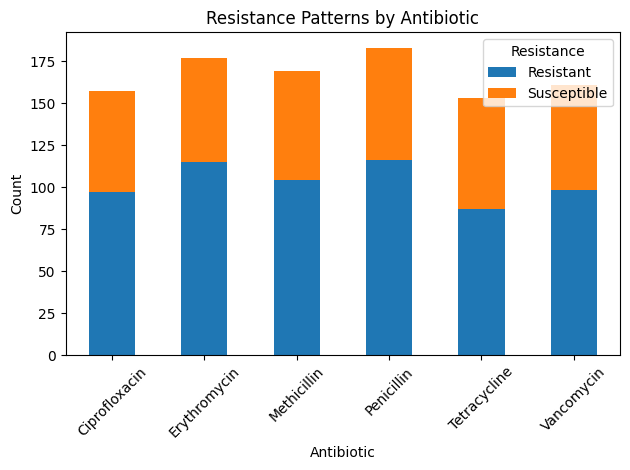

In [6]:
# Resistance patterns by species and antibiotic
plt.figure(figsize=(15, 8))

# Resistance by species
plt.subplot(1, 2, 1)
resistance_by_species = pd.crosstab(amr_df['species'], amr_df['resistance'])
resistance_by_species.plot(kind='bar', stacked=True)
plt.title('Resistance Patterns by Bacterial Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.legend(title='Resistance')
plt.xticks(rotation=45)

# Resistance by antibiotic
plt.subplot(1, 2, 2)
resistance_by_antibiotic = pd.crosstab(amr_df['antibiotic'], amr_df['resistance'])
resistance_by_antibiotic.plot(kind='bar', stacked=True)
plt.title('Resistance Patterns by Antibiotic')
plt.xlabel('Antibiotic')
plt.ylabel('Count')
plt.legend(title='Resistance')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

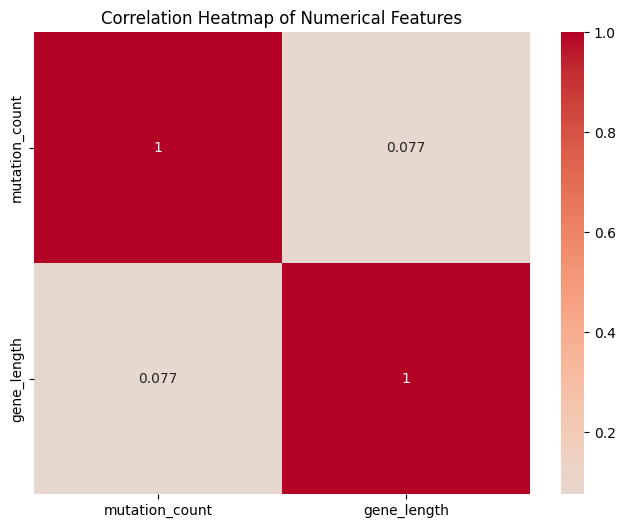

In [7]:
# Interactive visualization with Plotly
fig = px.sunburst(amr_df, path=['species', 'antibiotic', 'resistance'],
                  title='Antibiotic Resistance Patterns by Species and Antibiotic')
fig.show()

# Correlation heatmap for numerical features
numerical_df = amr_df.select_dtypes(include=[np.number])
if not numerical_df.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

In [8]:
# Machine Learning: Predict antibiotic resistance
def prepare_ml_data(df):
    """Prepare data for machine learning"""
    # Select features and target
    features = ['species', 'amr_gene', 'antibiotic', 'mutation_count', 'gene_length']
    target = 'resistance'

    # Create feature matrix and target vector
    X = df[features].copy()
    y = df[target]

    # Encode categorical variables
    categorical_cols = ['species', 'amr_gene', 'antibiotic']
    label_encoders = {}

    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

    return X, y, label_encoders

# Prepare data
X, y, encoders = prepare_ml_data(amr_df)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (1000, 5)
Target distribution:
resistance
Resistant      617
Susceptible    383
Name: count, dtype: int64


Random Forest Classifier Performance:
              precision    recall  f1-score   support

   Resistant       0.60      0.72      0.65       185
 Susceptible       0.32      0.22      0.26       115

    accuracy                           0.53       300
   macro avg       0.46      0.47      0.46       300
weighted avg       0.49      0.53      0.50       300



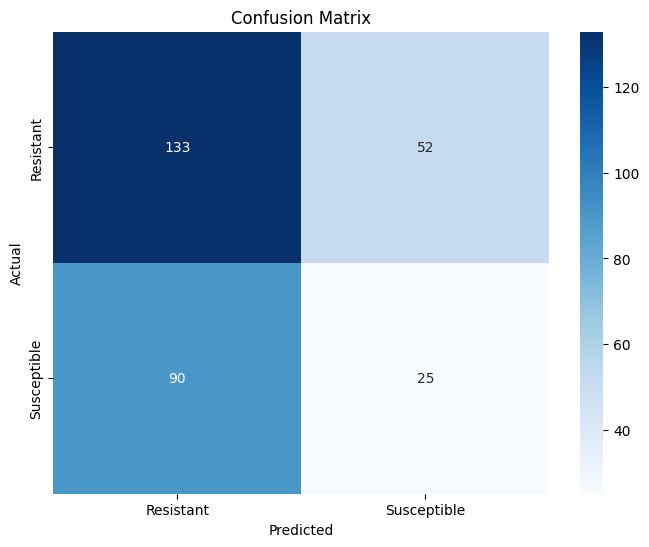

In [9]:
# Train Random Forest classifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model
print("Random Forest Classifier Performance:")
print("=" * 50)
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Resistant', 'Susceptible'],
            yticklabels=['Resistant', 'Susceptible'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

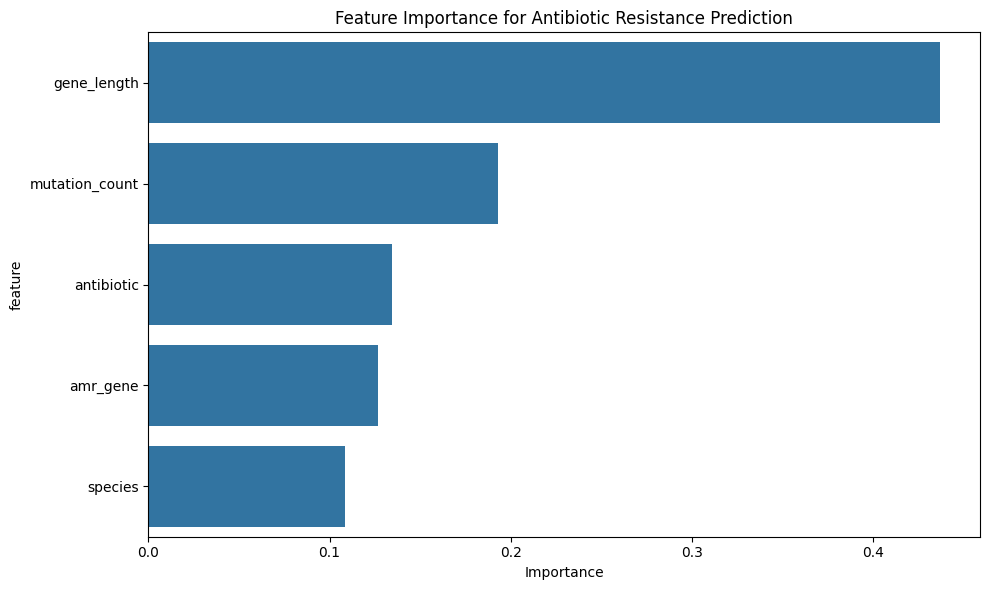

Top features for predicting antibiotic resistance:
          feature  importance
4     gene_length    0.437181
3  mutation_count    0.193225
2      antibiotic    0.134289
1        amr_gene    0.126637
0         species    0.108668


In [10]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance for Antibiotic Resistance Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top features for predicting antibiotic resistance:")
print(feature_importance.head(10))

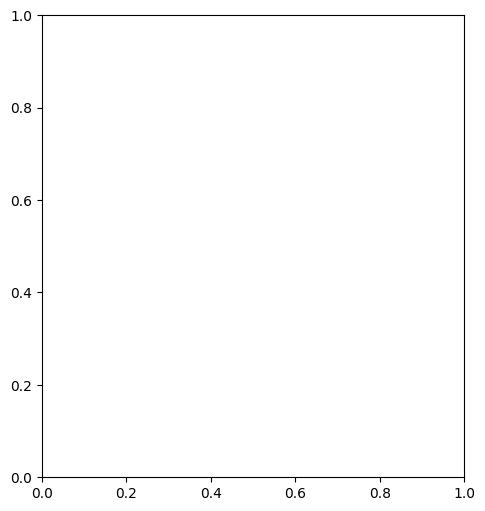

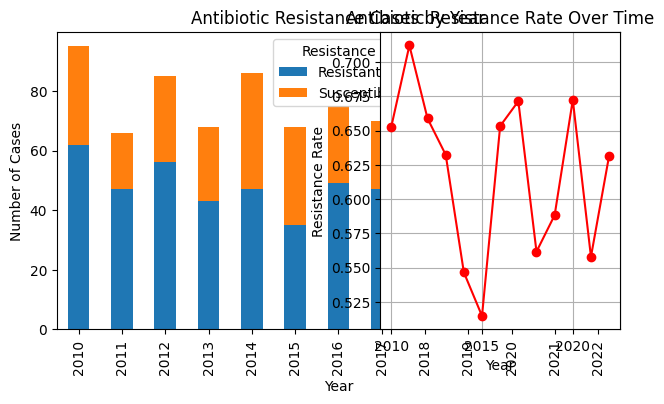

In [11]:
# Advanced analysis: Resistance trends over simulated time
# (Since we don't have temporal data, we'll simulate it)

# Create a simulated temporal analysis
np.random.seed(42)
years = np.random.choice(range(2010, 2023), len(amr_df))
amr_df['year'] = years

# Analyze resistance trends over time
yearly_resistance = amr_df.groupby(['year', 'resistance']).size().unstack(fill_value=0)
yearly_resistance['resistance_rate'] = yearly_resistance['Resistant'] / (yearly_resistance['Resistant'] + yearly_resistance['Susceptible'])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
yearly_resistance[['Resistant', 'Susceptible']].plot(kind='bar', stacked=True)
plt.title('Antibiotic Resistance Cases by Year')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend(title='Resistance')

plt.subplot(1, 2, 2)
yearly_resistance['resistance_rate'].plot(kind='line', marker='o', color='red')
plt.title('Antibiotic Resistance Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Resistance Rate')
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Function to predict resistance for new samples
def predict_resistance(species, amr_gene, antibiotic, mutation_count, gene_length, model, encoders):
    """Predict antibiotic resistance for new samples"""

    # Prepare input data
    input_data = {
        'species': species,
        'amr_gene': amr_gene,
        'antibiotic': antibiotic,
        'mutation_count': mutation_count,
        'gene_length': gene_length
    }

    # Convert to DataFrame
    input_df = pd.DataFrame([input_data])

    # Encode categorical variables
    for col in ['species', 'amr_gene', 'antibiotic']:
        if col in encoders:
            # Handle unseen labels
            if input_data[col] in encoders[col].classes_:
                input_df[col] = encoders[col].transform([input_data[col]])[0]
            else:
                input_df[col] = -1  # Unknown label

    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0]

    return prediction, probability

# Example prediction
sample_pred, sample_prob = predict_resistance(
    species='E. coli',
    amr_gene='blaTEM',
    antibiotic='Penicillin',
    mutation_count=3,
    gene_length=1500,
    model=rf_model,
    encoders=encoders
)

print("Example Prediction:")
print(f"Predicted resistance: {sample_pred}")
print(f"Probability: Resistant={sample_prob[0]:.3f}, Susceptible={sample_prob[1]:.3f}")

Example Prediction:
Predicted resistance: Resistant
Probability: Resistant=0.840, Susceptible=0.160


In [13]:
# Summary statistics
print("ANTIBIOTIC RESISTANCE ANALYSIS SUMMARY")
print("=" * 50)

# Overall resistance rate
total_resistant = (amr_df['resistance'] == 'Resistant').sum()
resistance_rate = total_resistant / len(amr_df) * 100
print(f"Overall resistance rate: {resistance_rate:.2f}%")

# Most problematic combinations
problematic_combos = amr_df[amr_df['resistance'] == 'Resistant'].groupby(['species', 'antibiotic']).size().sort_values(ascending=False).head(5)
print("\nTop 5 most problematic species-antibiotic combinations:")
for (species, antibiotic), count in problematic_combos.items():
    print(f"  {species} - {antibiotic}: {count} cases")

# Gene prevalence in resistant strains
resistant_genes = amr_df[amr_df['resistance'] == 'Resistant']['amr_gene'].value_counts().head(5)
print("\nTop 5 AMR genes in resistant strains:")
for gene, count in resistant_genes.items():
    print(f"  {gene}: {count} occurrences")

ANTIBIOTIC RESISTANCE ANALYSIS SUMMARY
Overall resistance rate: 61.70%

Top 5 most problematic species-antibiotic combinations:
  E. coli - Erythromycin: 36 cases
  P. aeruginosa - Penicillin: 35 cases
  K. pneumoniae - Penicillin: 34 cases
  S. aureus - Erythromycin: 34 cases
  E. coli - Tetracycline: 31 cases

Top 5 AMR genes in resistant strains:
  qnrS: 110 occurrences
  blaTEM: 110 occurrences
  mecA: 107 occurrences
  ermB: 101 occurrences
  tetM: 98 occurrences
